In [1]:
from utils import *


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
%matplotlib inline



EJ_subdivisions = 50
EC_subdivisions = 50
EL_subdivisions = 50
# Initialize EJ values
EJ_values = np.linspace(4, 16, EJ_subdivisions)

one_two = []
differential_stark = []
qubit_zero_lamb = []
detunning = []
extents = []


# Loop through each EJ value
existing_chunk_num = 0
for EJ in EJ_values:
    # Generate discrete grid for EC and EL based on constraints
    EC_values = np.linspace(EJ / 10, EJ / 2, EC_subdivisions)
    EL_values = np.linspace( 0.01, 1, EL_subdivisions)
    
    EC_grid, EL_grid = np.meshgrid(EC_values, EL_values)
    EC_flat = EC_grid.flatten()
    EL_flat = EL_grid.flatten()
    EC_chunks = np.array_split(EC_flat, total_jobs // len(EJ_values))
    EL_chunks = np.array_split(EL_flat, total_jobs // len(EJ_values))

    for EC_chunk, EL_chunk in zip(EC_chunks, EL_chunks):
        job = search_job(EJ, EC_chunk, EL_chunk)
        with open(f'{existing_chunk_num}.pkl', 'wb') as f:
            pickle.dump(job, f)
        existing_chunk_num += 1
    # (transition,
    #  sum_of_differential_stark_on_qubit_12,
    #  sum_of_qubit_zero_lamb_on_osc,
    #  detunning_qubit01)  = np.vectorize(get_estimations)(EJ, EC_grid, EL_grid)
    # one_two.append(transition)
    # differential_stark.append(sum_of_differential_stark_on_qubit_12)
    # qubit_zero_lamb.append(sum_of_qubit_zero_lamb_on_osc)
    # detunning.append(detunning_qubit01)

    # # extents.append([EC_values[0], EC_values[-1], EL_values[0], EL_values[-1]])
    # num_done += 1
    # clear_output()
    # print(f"done: {num_done}/{EJ_subdivisions}")

def pack_pkl_files_to_zip(zip_filename="param_search.zip"):
    # Create a new ZIP file
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Loop through all files in the current directory
        for filename in os.listdir('.'):
            # Check if the file is a .pkl file with an integer name
            name, ext = os.path.splitext(filename)
            if ext == '.pkl' and name.isdigit():
                # Add the file to the ZIP
                zipf.write(filename)
                # Delete the .pkl file
                os.remove(filename)
                
pack_pkl_files_to_zip()


NameError: name 'EC_subdivisions' is not defined

In [5]:

EJ = 10

EC_values = np.linspace(EJ / 10, EJ / 2, 10)
EL_values = np.linspace( 0.01, 1, 10)

EC_grid, EL_grid = np.meshgrid(EC_values, EL_values)

In [7]:
1000//50

20

In [93]:
from matplotlib.colors import LogNorm
from ipywidgets import interact, FloatSlider
import matplotlib.pyplot as plt
import numpy as np

# Assuming EJ_values, one_two, detunning, qubit_zero_lamb, differential_stark, extents are already defined

def plot_all(EJ):
    idx = np.argmin(np.abs(EJ_values - EJ))
    
    plt.figure(figsize=(10, 8))
    
    plt.subplot(2, 2, 1)
    plt.imshow(one_two[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm())
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'one-two transition for EJ = {EJ}')
    
    plt.subplot(2, 2, 2)
    plt.imshow(detunning[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm())
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'detunning for EJ = {EJ}')
    
    plt.subplot(2, 2, 3)
    plt.imshow(qubit_zero_lamb[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm())
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'qubit_zero_lamb for EJ = {EJ}')
    
    plt.subplot(2, 2, 4)
    plt.imshow(differential_stark[idx], extent=extents[idx], origin='lower', aspect='auto', norm=LogNorm())
    plt.colorbar(label='')
    plt.xlabel('EC')
    plt.ylabel('EL')
    plt.title(f'differential_stark_on_qubit_12 for EJ = {EJ}')
    
    plt.tight_layout()
    plt.show()

interact(plot_all, EJ=FloatSlider(min=EJ_values[0], max=EJ_values[-1], step=(EJ_values[1]-EJ_values[0]), value=EJ_values[0]))


interactive(children=(FloatSlider(value=4.0, description='EJ', max=16.0, min=4.0, step=0.24489795918367374), O…

<function __main__.plot_all(EJ)>

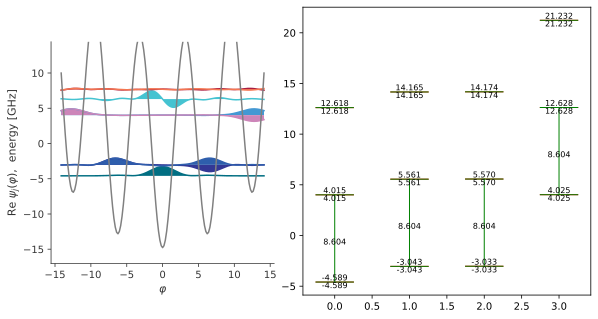

In [83]:
g_strength = 0.3
EJ = 14.77
EC = 3.3
EL = 0.1



qubit_level = 5
osc_level = 6
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=20,truncated_dim=qubit_level)
q_evals = qbt.eigenvals()
E_osc = q_evals[3] - q_evals[0]-0.01

osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())

plot_specturum(qbt, osc, hilbertspace)

In [90]:
def detuning(ql1,ql2):
    energies=  hilbertspace.eigenvals(qubit_level*osc_level)
    return abs((energies[product_to_dressed[(ql1,1)]]-energies[product_to_dressed[(ql1,0)]])  -
                    (energies[product_to_dressed[(ql2,1)]]-energies[product_to_dressed[(ql2,0)]]))


detunning_qubit01 = detuning(0,1) + detuning(0, 2)

detunning_qubit01

0.0002645939829477584

In [88]:
energies=  hilbertspace.eigenvals(qubit_level*osc_level)

energies[product_to_dressed[(0,1)]]-energies[product_to_dressed[(0,0)]],   energies[product_to_dressed[(1,1)]]-energies[product_to_dressed[(1,0)]],   energies[product_to_dressed[(2,1)]]-energies[product_to_dressed[(2,0)]]

(8.603679376088568, 8.603809966627622, 8.603813379532461)

10.0%. Run time:   0.33s. Est. time left: 00:00:00:02
20.0%. Run time:   0.75s. Est. time left: 00:00:00:03
30.0%. Run time:   1.21s. Est. time left: 00:00:00:02
40.0%. Run time:   1.66s. Est. time left: 00:00:00:02
50.0%. Run time:   2.16s. Est. time left: 00:00:00:02
60.0%. Run time:   2.63s. Est. time left: 00:00:00:01
70.0%. Run time:   3.08s. Est. time left: 00:00:00:01
80.0%. Run time:   3.51s. Est. time left: 00:00:00:00
90.0%. Run time:   3.93s. Est. time left: 00:00:00:00
Total run time:   4.28s
10.0%. Run time:   0.32s. Est. time left: 00:00:00:02
20.0%. Run time:   0.74s. Est. time left: 00:00:00:02
30.0%. Run time:   1.18s. Est. time left: 00:00:00:02
40.0%. Run time:   1.63s. Est. time left: 00:00:00:02
50.0%. Run time:   2.07s. Est. time left: 00:00:00:02
60.0%. Run time:   2.53s. Est. time left: 00:00:00:01
70.0%. Run time:   2.98s. Est. time left: 00:00:00:01
80.0%. Run time:   3.43s. Est. time left: 00:00:00:00
90.0%. Run time:   3.88s. Est. time left: 00:00:00:00
Tota

 /home/jiakai/.local/lib/python3.10/site-packages/jax/_src/array.py: 363

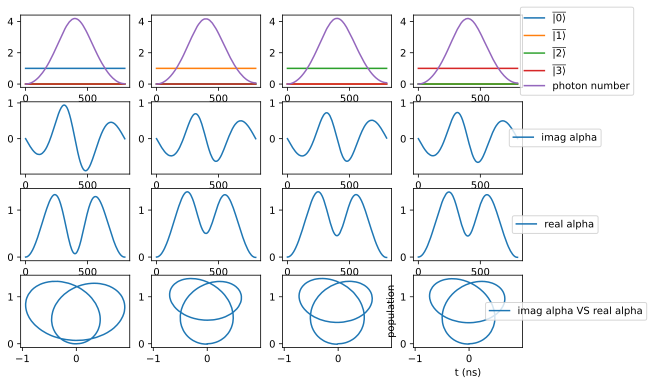

In [59]:


a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


tot_time = 800
tlist = np.linspace(0, tot_time, tot_time*2)

A_square = 0.002

def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.0
decay_term = kappa*a


results = []
for i in range(4):
    temp = solve_with_mesolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        # c_ops= [ decay_term],
        options=qutip.Options(store_states=True,nsteps=20000,num_cpus = 7),
        
    )
    results.append(temp)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

In [49]:
interactive_heatmap(results[0], product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=1599), Output…